## **Transfer Learning**

Not only can training a model from scratch can be time consuming and computationally heavy, in cases where we need to use a large model but we only have a small amount of data, overfitting is almost guaranteed to occur!
In this notebook we look at how we can take a network trained on one dataset and use the learned weights as a step up, allowing us to achieve good results with little effort.<br>

### Our dataset: STL10
STL10 has **10 classes** (airplane, bird, car, cat, deer, dog, horse, monkey,
ship, truck) but only **5000 training images** — small enough that training from
scratch would overfit, which makes it perfect for showing why transfer learning
helps.

### What we'll do (the whole recipe in 4 steps)
| Step | What | Why |
|------|------|-----|
| 1️⃣ | Load a **pretrained** ResNet18 | reuse ImageNet's learned features |
| 2️⃣ | **Freeze** the backbone | keep those features, train fast |
| 3️⃣ | **Replace the final layer** (1000 → 10 outputs) | adapt it to STL10's classes |
| 4️⃣ | **Train** only the new layer, then evaluate | learn our task with little data |
---

## **Imports**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader 
import torchvision.models as models

import time
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


## **Settings**


In [ ]:
batch_size    = 64        # images per mini-batch
num_epochs    = 5         # passes over the training set
learning_rate = 1e-3      # step size for the optimizer
image_size    = 96        # STL10 images are 96x96

dataset_root = os.path.abspath(os.path.join(".", "..","..", "Datasets"))    # where STL10 will be downloaded


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## **Preprocessing**

The pretrained ResNet was trained on ImageNet images that were normalized with
**specific** per-channel mean and standard deviation values. If we don't normalize
**our** images the exact same way, the pretrained feature detectors get inputs
they don't "expect" and accuracy drops.

So we **must** use these exact numbers:
- **mean** = `[0.485, 0.456, 0.406]`
- **std**  = `[0.229, 0.224, 0.225]`


In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
])

## **Load STL10 (built into torchvision)**
No custom dataset class needed — `torchvision` downloads and loads STL10 for us.
It comes with a **train** split (5000 images) and a **test** split (8000 images).


In [19]:
# Full training set with augmentation, and a clean copy for validation
train_data = datasets.STL10(dataset_root, split='train', download=True, transform=transform)
test_data = datasets.STL10(dataset_root, split='test', download=True, transform=transform)


# Split training data into train and validation set with 90/10% training/validation split
validation_split = 0.9

n_train_examples = int(len(train_data)*validation_split)
n_valid_examples = len(train_data) - n_train_examples
train_data, valid_data = torch.utils.data.random_split(train_data, [n_train_examples, n_valid_examples],
                                                       generator=torch.Generator().manual_seed(42))

print(f"Train: {len(train_data)} | Val: {len(valid_data)} | Test: {len(test_data)}")


Train: 4500 | Val: 500 | Test: 8000


In [20]:
classes =['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey','ship', 'truck']
idx_to_class = {i: name for i, name in enumerate(classes)}


## **DataLoaders**
The `DataLoader` serves images in mini-batches. We **shuffle the training data**
(so the model doesn't learn the order) but not validation or test.

> ⚠️ We use `num_workers=0` here. On Windows / Jupyter, using extra workers can
> make `next(iter(loader))` hang for a long time. `0` loads in the main process
> and is reliable.

In [21]:
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,  num_workers=0)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False, num_workers=0)

## **Look at a batch**
Before training, confirm the images and labels look right. We **un-normalize**
first (reverse the mean/std) so the colors display correctly.

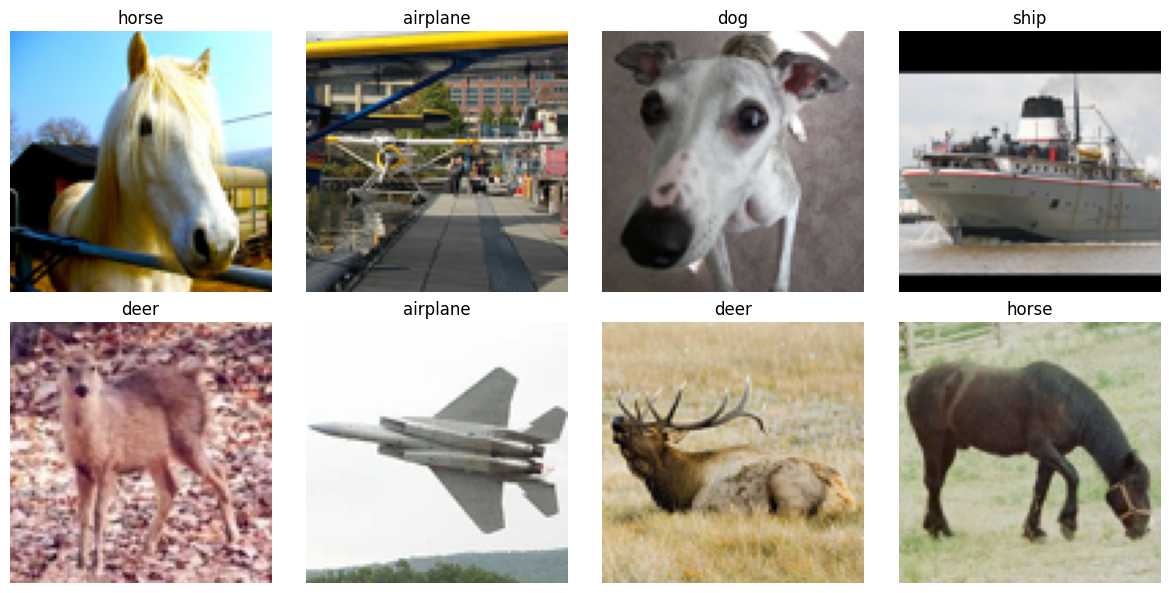

In [22]:
def imshow(img_tensor):
    mean = np.array(IMAGENET_MEAN); std = np.array(IMAGENET_STD)
    npimg = img_tensor.numpy().transpose((1, 2, 0)) * std + mean
    plt.imshow(np.clip(npimg, 0, 1)); plt.axis("off")

images, labels = next(iter(train_loader))
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow(images[i])
    plt.title(idx_to_class[labels[i].item()])
plt.tight_layout(); plt.show()

## **Create the pretrained network**
First set pretrained=True or weights="IMAGENET1K_V1" and train collecting the results <br>

In [23]:
model = models.resnet18(weights="IMAGENET1K_V1")
# or you can use 
#model = models.resnet18(pretrained=True)

print(model.fc)   # the original final layer: 512 -> 1000 (ImageNet classes)

Linear(in_features=512, out_features=1000, bias=True)


## **Freeze the backbone**

"Freezing" means **don't update these weights during training**. We set
`requires_grad = False` on every parameter, so the optimizer leaves the
pretrained feature detectors untouched.

**Why?** Those features are already great. We only need to train a small new
layer on top — that's fast and avoids overfitting our small dataset.

In [24]:
for param in model.parameters():
    param.requires_grad = False

# quick check: nothing is trainable yet
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters after freezing: {trainable}")   # -> 0

Trainable parameters after freezing: 0


## **Replace the final layer**
ResNet's last layer (`model.fc`) outputs **1000** numbers (one per ImageNet
class). STL10 has **10** classes, so we swap it for a fresh `Linear` layer with
10 outputs.

The new layer is **trainable by default** — so after this, exactly one layer will
learn, and the rest stays frozen. 🎯

In [25]:
num_ftrs = model.fc.in_features          # 512 for ResNet18
model.fc = nn.Linear(num_ftrs, len(classes))   # new layer: 512 -> 10
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,}  /  Total: {total:,}")
print("Only the new final layer will be trained.")

Trainable: 5,130  /  Total: 11,181,642
Only the new final layer will be trained.


## **Loss function & optimizer**
- **Loss** = `CrossEntropyLoss` (standard for multi-class classification)
- **Optimizer** = `Adam`, but we hand it **only the parameters that require grad**
  (the new layer). It can't touch the frozen backbone.

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate
)

### Save / load helper functions
These save everything needed to either resume training later or just load the
model for inference: the model weights, the optimizer state, the epoch, the best
validation accuracy, and the history.

In [27]:
import os

save_dir  = "./checkpoints/Freeze/"
save_path = os.path.join(save_dir, "resnet18_stl10.pt")
os.makedirs(save_dir, exist_ok=True)


def save_checkpoint(model, optimizer, epoch, best_valid_acc, history, path):
    """Save everything needed to resume training or load the model later."""
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_valid_acc": best_valid_acc,
        "history": history,
    }, path)
    print(f"Saved checkpoint to {path} (val_acc={best_valid_acc*100:.2f}%)")


def load_checkpoint(model, optimizer, path):
    """Load a saved checkpoint back into the model and optimizer."""
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch    = checkpoint["epoch"]
    best_valid_acc = checkpoint["best_valid_acc"]
    history        = checkpoint["history"]
    print(f"Loaded checkpoint from {path} "
          f"(epoch {start_epoch}, val_acc={best_valid_acc*100:.2f}%)")
    return start_epoch, best_valid_acc, history

## **The training loop**

This is the **most important cell to understand**. For every mini-batch we do the
same 5 steps. Read the comments — this is what *every* PyTorch training loop does:

```
1. forward   → run images through the model to get predictions
2. loss      → measure how wrong the predictions are
3. zero_grad → clear old gradients from the last step
4. backward  → compute new gradients (how to adjust weights)
5. step      → nudge the weights to reduce the loss
```

We wrap this in two small helper **functions** (not a giant class) so you can read
each one top-to-bottom.

In [28]:
def train_one_epoch(model, loader):
    model.train()                     # training mode (enables dropout, etc.)
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)            # 1. forward
        loss = criterion(outputs, labels)  # 2. loss

        optimizer.zero_grad()              # 3. clear old gradients
        loss.backward()                    # 4. backward (compute gradients)
        optimizer.step()                   # 5. update the weights

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader):
    model.eval()                      # eval mode (no dropout)
    correct, total = 0, 0
    with torch.no_grad():             # no gradients needed -> faster, less memory
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            correct += (outputs.argmax(1) == labels).sum().item()
            total   += labels.size(0)
    return correct / total

## **Run training**
Now we just call our two functions once per epoch and record the numbers so we can
plot them afterwards. 

In [29]:
history = {"train_loss": [], "train_acc": [], "val_acc": []}
start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_acc = evaluate(model, valid_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"train_loss={train_loss:.4f} | "
          f"train_acc={train_acc*100:.2f}% | "
          f"val_acc={val_acc*100:.2f}%")

print(f"\nTraining time: {time.time() - start_time:.1f} seconds")
print(f"Best validation accuracy: {max(history['val_acc'])*100:.2f}%")

Training:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 1/5 | train_loss=1.3816 | train_acc=56.04% | val_acc=70.40%


Training:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 2/5 | train_loss=0.7681 | train_acc=76.49% | val_acc=74.60%


Training:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 3/5 | train_loss=0.6470 | train_acc=79.53% | val_acc=75.20%


Training:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 4/5 | train_loss=0.5842 | train_acc=81.20% | val_acc=77.40%


Training:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 5/5 | train_loss=0.5456 | train_acc=81.93% | val_acc=76.80%

Training time: 11.8 seconds
Best validation accuracy: 77.40%


## **Plot the learning curves**

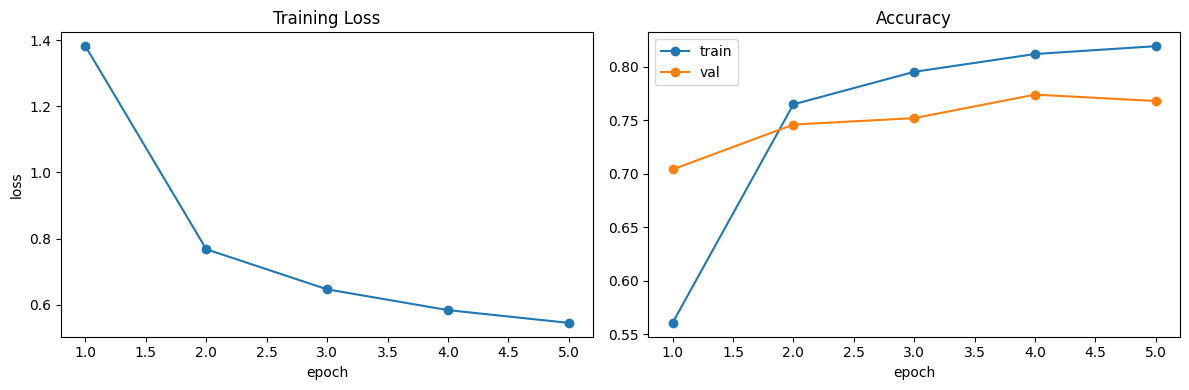

In [30]:
epochs = range(1, num_epochs + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], marker="o")
plt.title("Training Loss"); plt.xlabel("epoch"); plt.ylabel("loss")

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], marker="o", label="train")
plt.plot(epochs, history["val_acc"],   marker="o", label="val")
plt.title("Accuracy"); plt.xlabel("epoch"); plt.legend()

plt.tight_layout(); plt.show()

## **Evaluate on the test set**
This is the real measure — images the model never saw during training. A
**classification report** shows precision/recall for each of the 10 classes.

In [31]:
from sklearn.metrics import classification_report

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing", leave=False):
        preds = model(images.to(device)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_true.extend(labels.tolist())

test_acc = np.mean(np.array(all_preds) == np.array(all_true))
print(f"✅ Test accuracy: {test_acc*100:.2f}%\n")
print(classification_report(all_true, all_preds, target_names=classes))

Testing:   0%|          | 0/125 [00:00<?, ?it/s]

✅ Test accuracy: 78.39%

              precision    recall  f1-score   support

    airplane       0.80      0.84      0.82       800
        bird       0.87      0.79      0.83       800
         car       0.86      0.90      0.88       800
         cat       0.69      0.68      0.69       800
        deer       0.78      0.73      0.75       800
         dog       0.70      0.71      0.71       800
       horse       0.78      0.78      0.78       800
      monkey       0.74      0.81      0.77       800
        ship       0.81      0.88      0.84       800
       truck       0.82      0.73      0.77       800

    accuracy                           0.78      8000
   macro avg       0.78      0.78      0.78      8000
weighted avg       0.78      0.78      0.78      8000



## **See predictions (green = right, red = wrong)**

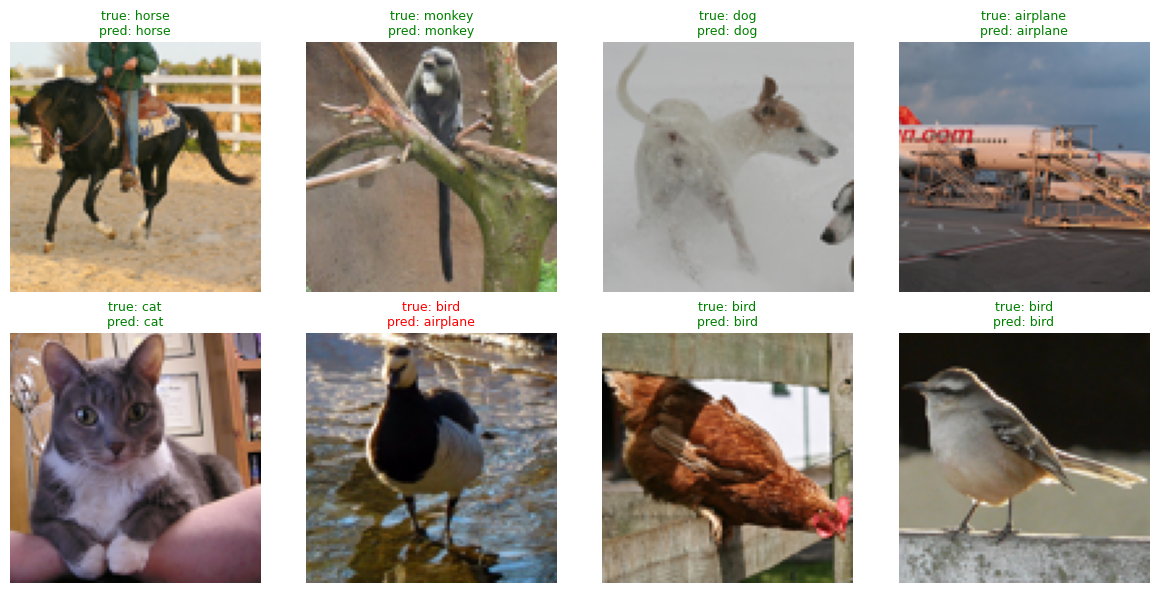

In [32]:
images, labels = next(iter(test_loader))
model.eval()
with torch.no_grad():
    preds = model(images.to(device)).argmax(1).cpu()

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow(images[i])
    t, p = idx_to_class[labels[i].item()], idx_to_class[preds[i].item()]
    plt.title(f"true: {t}\npred: {p}", color=("green" if t == p else "red"), fontsize=9)
plt.tight_layout(); plt.show()

---
## **Fine-tuning (the second stage) and saving the model**
So far we only trained the new last layer (feature extraction). To squeeze out
more accuracy, we can unfreeze the whole backbone and train it a little more, but
with a much smaller learning rate so we don't destroy the good pretrained features.

In this stage we also save the model after every epoch, so the latest version is
always kept on disk.

In [ ]:
import os
save_dir_unfreeze  = "./checkpoints/Unfreeze"
save_path = os.path.join(save_dir_unfreeze, "resnet18_stl10.pt")
os.makedirs(save_dir_unfreeze, exist_ok=True)

### Unfreeze, fine-tune, and save the model
We start by unfreezing the backbone, then train with a small learning rate and
save the model after each epoch.

In [ ]:
# Unfreeze the whole backbone so every layer can learn
for param in model.parameters():
    param.requires_grad = True

# New optimizer over ALL parameters, with a SMALL learning rate
# (small, so we refine the pretrained features instead of destroying them)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

finetune_epochs = 3
best_valid_acc  = 0.0

for epoch in range(finetune_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_acc = evaluate(model, valid_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"[fine-tune] Epoch {epoch+1}/{finetune_epochs} | "
          f"train_acc={train_acc*100:.2f}% | val_acc={val_acc*100:.2f}%")

    # Save the checkpoint after every epoch (overwrites the previous one)
    best_valid_acc = val_acc
    save_checkpoint(model, optimizer, epoch, best_valid_acc, history, save_path)

### Load the saved model back
Run this later (for inference, or to resume training) to restore the saved model.

In [ ]:
start_epoch, best_valid_acc, history = load_checkpoint(model, optimizer, save_path)